In [1]:
import os

import gc
import yaml

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
import matplotlib.colors as mcolors
from matplotlib.font_manager import fontManager, FontProperties
import os
fontManager.addfont('/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/Arial.ttf')
font = FontProperties(fname='/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name


tick_font = FontProperties(fname='/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/Arial-ItalicMT.otf', style = 'italic')

from matplotlib_scalebar.scalebar import ScaleBar

In [11]:
def create_custom_cmap_from_hex(name, hex_colors, positions=None):
    rgb_colors = [mcolors.hex2color(c) for c in hex_colors]
    if positions is None:
        positions = np.linspace(0, 1, len(hex_colors))
    else:
        positions = np.array(positions) / 100.0
    cmap = mcolors.LinearSegmentedColormap.from_list(name, 
                                                       list(zip(positions, rgb_colors)))
    return cmap

hex_colors = ['#b4dae5', '#fcfdff','#fc0703', '#8c000a']
positions = [0, 33, 66, 100] 

my_cmap = create_custom_cmap_from_hex('my_custom_cmap', hex_colors, positions)
use_genes = [
    'Grin2a', 'Grin2b', 'Slc32a1', 'Gad1', 'Pou3f1', 'Syt6', 'Fezf2',
    'Tshz2', 'Rorb', 'Nptx2', 'Cux2', 'Otof', 'Sncg', 'Lamp5', 'Cnr1',
    'Pvalb', 'Reln', 'Lhx6', 'Gjb6', 'Mog', 'Serpinf1', 'Cldn5', 'Ctss', 'Pdgfra'
]

colormap = {
    'L5 ET 1': '#375998', 'L5 ET 2': '#c04424', 'L6 CT 1': '#18bd50',
    'L6 CT 2': '#f70086', 'L6 CT 3': '#f700bd', 'L5/6 NP': '#f7e43c', 'L6 CT 4': '#f5e1a2', 
    'L4/5 IT 2': '#f69f9e', 'L5 IT 3': '#b00e9f', 'L5 IT 1': '#278357', 'L6 IT 2': '#7822b2', 
    'L2/3 IT 2': '#91ad29', 'L2/3 IT 1': '#1effcd', 'L2/3 IT 3': '#2ed8ff', 'L2/3 IT 4': '#dc9cfa', 'L4/5 IT 1': '#a900fa', 
    'L5 IT 2': '#84660c', 'L6 IT 1': '#bd73a5', 
    'Lamp5 3': '#7e2d20', 'Lamp5 1': '#aaf302', 'Lamp5 2': '#bbccff', 'Sncg 1': '#bd0032', 'Vip 1': '#f1a623', 'Vip 2': '#b2446c', 
    'Pvalb 5': '#f28301', 'Pvalb 6': '#a2c9ee', 'Pvalb 1': '#3b00fa', 'Pvalb 2': '#222222', 'Pvalb 3': '#f1c201', 'Pvalb 4': '#865691', 'Sst 1': '#838381', 
    'Sst 5': '#f89279', 'Sst 6': '#614e97', 'Sst 2': '#008756', 'Sst 4': '#1a66a2', 
    'Sncg 2': '#c1b080', 'Sst 3': '#e28dac', 
    'Astro 3': '#f5212f', 'Astro 1': '#5b5156', 'Astro 2': '#e1e1e1', 
    'Oligo 1': '#2a7f91', 'Oligo 2': '#d75ff7', 
    'VLMC': '#dbd200', 
    'Endo 5': '#af0168', 'Endo 3': '#3182fd', 'Endo 4': '#fdae16', 'Endo 1': '#fd02f9', 'Endo 2': '#0fff33', 
    'Microglia 1': '#b4eeb4', 'Microglia 2': '#7ed6d0',
    'OPC 1': '#683b79', 'OPC 2': '#67afff',
}
colormap = {
    'Astro': '#a900fa',    'Endo': '#953e0d', 'L2/3 IT': '#362683', 'L4/5 IT': '#266adb','L5 ET': '#a1bd6e', 'L5 IT': '#279acb', 
    'L5/6 NP': '#f4bc48', 'L6 CT': '#f6fc34', 'L6 IT': '#40b69e', 'Lamp5': '#160084','Microglia': '#f4917c','OPC': '#e926a5',
    'Oligo': '#624d95','Pvalb': '#6900a2','Sncg': '#ab228d', 'Sst': '#db6163', 'VLMC': '#cbcd25','Vip': '#f4a740',
}
categories_order = [
        'L5 ET 1',  'L5 ET 2', 'L6 CT 1','L6 CT 2', 'L6 CT 3', 'L5/6 NP', 'L6 CT 4', 
        'L4/5 IT 2', 'L5 IT 3', 'L5 IT 1', 'L6 IT 2', 
        'L2/3 IT 2', 'L2/3 IT 1', 'L2/3 IT 3', 'L2/3 IT 4', 'L4/5 IT 1', 
        'L5 IT 2', 'L6 IT 1', 
        'Lamp5 3', 'Lamp5 1', 'Lamp5 2', 'Sncg 1', 'Vip 1', 'Vip 2', 
        'Pvalb 5', 'Pvalb 6', 'Pvalb 1', 'Pvalb 2', 'Pvalb 3', 'Pvalb 4', 'Sst 1', 
        'Sst 5', 'Sst 6', 'Sst 2', 'Sst 4', 
        'Sncg 2', 'Sst 3', 
        'Astro 3', 'Astro 1', 'Astro 2', 
        'Oligo 1', 'Oligo 2', 
        'VLMC', 
        'Endo 5', 'Endo 3', 'Endo 4', 'Endo 1', 'Endo 2', 
        'Microglia 1', 'Microglia 2',
        'OPC 1', 'OPC 2',
    ]

In [3]:
def plot_spatial(adata: sc.AnnData, 
                 color_col: str, 
                 output_dir: str = None, 
                 scale_factor: float = 0.1, 
                 figsize: tuple = (8, 8),
                 dpi: int = 150, 
                 colormap: dict = None):
    """使用 sc.pl.embedding 绘制空间分布图，并添加 scale bar"""
    if "spatial" not in adata.obsm:
        print("[警告] 没有 'spatial' 数据，跳过空间图")
        return

    # os.makedirs(output_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_alpha(0)   # figure 背景透明
    ax.set_facecolor('none') # axes 背景透明
    
    sc.pl.embedding(
        adata,
        basis="spatial",                # 使用空间坐标
        color=color_col,
        ax=ax,
        show=False,
        legend_loc="right margin",      # 图例放在右侧
        title=f"Spatial ({color_col})",
        s = 2,
        frameon=False,                  # 不显示坐标轴框
        palette = colormap
    )
    ax.set_aspect("equal")

    # 添加比例尺
    scalebar = ScaleBar(
        scale_factor, "µm", fixed_value=500,
        location="lower left", frameon=False
    )
    ax.add_artist(scalebar)

    safe_color = color_col.replace("/", "_")
    # save_path = os.path.join(output_dir, f"spatial_{safe_color}.pdf")
    # fig.savefig(save_path, dpi=dpi, bbox_inches="tight", transparent=True, facecolor='none')
    # plt.close(fig)
    # print(f"空间图已保存: {save_path}")
    plt.show()
    

In [4]:
def plot_umap(adata: sc.AnnData, 
              umap_key: str, 
              color_col: str = None, 
              output_dir: str = None, 
              figsize: tuple = (10, 10), 
              dpi: int = 300,
              colormap = None,
              use_raw = None):
    """绘制 UMAP 图（颜色来自 obs 列）"""
    # 优先使用指定 key，否则回退到 'umap'
    if umap_key not in adata.obsm:
        if "umap" in adata.obsm:
            umap_key = "umap"
        else:
            print(f"[警告] 找不到 umap 数据 '{umap_key}'，跳过")
            return

    # os.makedirs(output_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_alpha(0)   # figure 背景透明
    ax.set_facecolor('none') # axes 背景透明
    
    sc.pl.embedding(
        adata, basis=umap_key, color=color_col,
        ax=ax, show=False, legend_loc="right margin",
        title=f"UMAP ({umap_key})  –  {color_col}",
        palette = colormap,
        frameon = False,
        use_raw = use_raw
    )
    ax.set_aspect("equal")
    safe_name = umap_key.replace("/", "_")
    safe_color = color_col.replace("/", "_")
    # save_path = os.path.join(output_dir, f"umap_{safe_name}_{safe_color}.pdf")
    # fig.savefig(save_path, dpi=dpi, bbox_inches="tight", transparent=True, facecolor='none')
    # plt.close(fig)
    # print(f"UMAP 图已保存: {save_path}")
    plt.show()

In [21]:
adata = sc.read_h5ad('/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/01_merfish_pfc_v3/integrated_adatas/integrated.h5ad')
adata

AnnData object with n_obs × n_vars = 39592 × 416
    obs: 'nCount_RNA', 'nFeature_RNA', 'CellType', 'subcluster', 'L3_cluster', 'slice', 'PFC', 'CCF_metaRegion', 'Cluster', 'batch', 'leiden_cell_embedding_r1.5', 'leiden_niche_embedding_r1.0'
    uns: 'cell_embedding_umap', 'leiden_cell_embedding_r1.5', 'leiden_niche_embedding_r1.0', 'neighbors', 'niche_embedding_umap'
    obsm: 'cell_embedding', 'cell_embedding_umap', 'niche_embedding', 'niche_embedding_umap', 'spatial', 'umap'
    obsp: 'connectivities', 'distances'

In [29]:
adata.obs

,nCount_RNA,nFeature_RNA,CellType,subcluster,L3_cluster,slice,PFC,CCF_metaRegion,Cluster,batch,leiden_cell_embedding_r1.5,leiden_niche_embedding_r1.0
5e7c3fc0-aa92-45d4-98dd-72cb62ef6683-0,153,88,Ext,L6 CT 2,L6 CT,slice_0,Out,TTd,L6 CT,0,12,6
e6aeab0d-97d7-41c2-988a-44511309f512-0,140,91,Ext,L6 CT 2,L6 CT,slice_0,Out,fiber tracts,L6 CT,0,12,6
7b72b5c5-dba0-4fc9-ad24-4d5a1ee75aca-0,217,111,Ext,L6 CT 2,L6 CT,slice_0,Out,LSr,L6 CT,0,8,8
ea3c4ccb-2a93-4242-b337-23f2e2f6efed-0,164,106,Ext,L6 CT 2,L6 CT,slice_0,Out,fiber tracts,L6 CT,0,12,6
1fa1b87c-5d0e-4256-8704-c6edd57c0f13-0,226,118,Ext,L6 CT 2,L6 CT,slice_0,Out,fiber tracts,L6 CT,0,12,6
...,...,...,...,...,...,...,...,...,...,...,...,...
e9feae70-856a-4a3b-846a-25977f1707af-4,139,64,Astro,Astro 1,Astro,slice_4,Out,ORBvl,Astro,4,11,8
5b932b9a-cdee-4f43-b635-319dbb6493cf-4,136,68,Astro,Astro 1,Astro,slice_4,Out,OLF,Astro,4,14,6
24416333-e6d2-4315-9177-09d6f51341d8-4,89,56,Oligo,Oligo 2,Oligo,slice_4,Out,ORBvl,Oligo,4,7,5
d2f73131-318b-418a-aa75-37fbd871b0a9-4,137,64,Astro,Astro 1,Astro,slice_4,Out,AONm,Astro,4,11,8


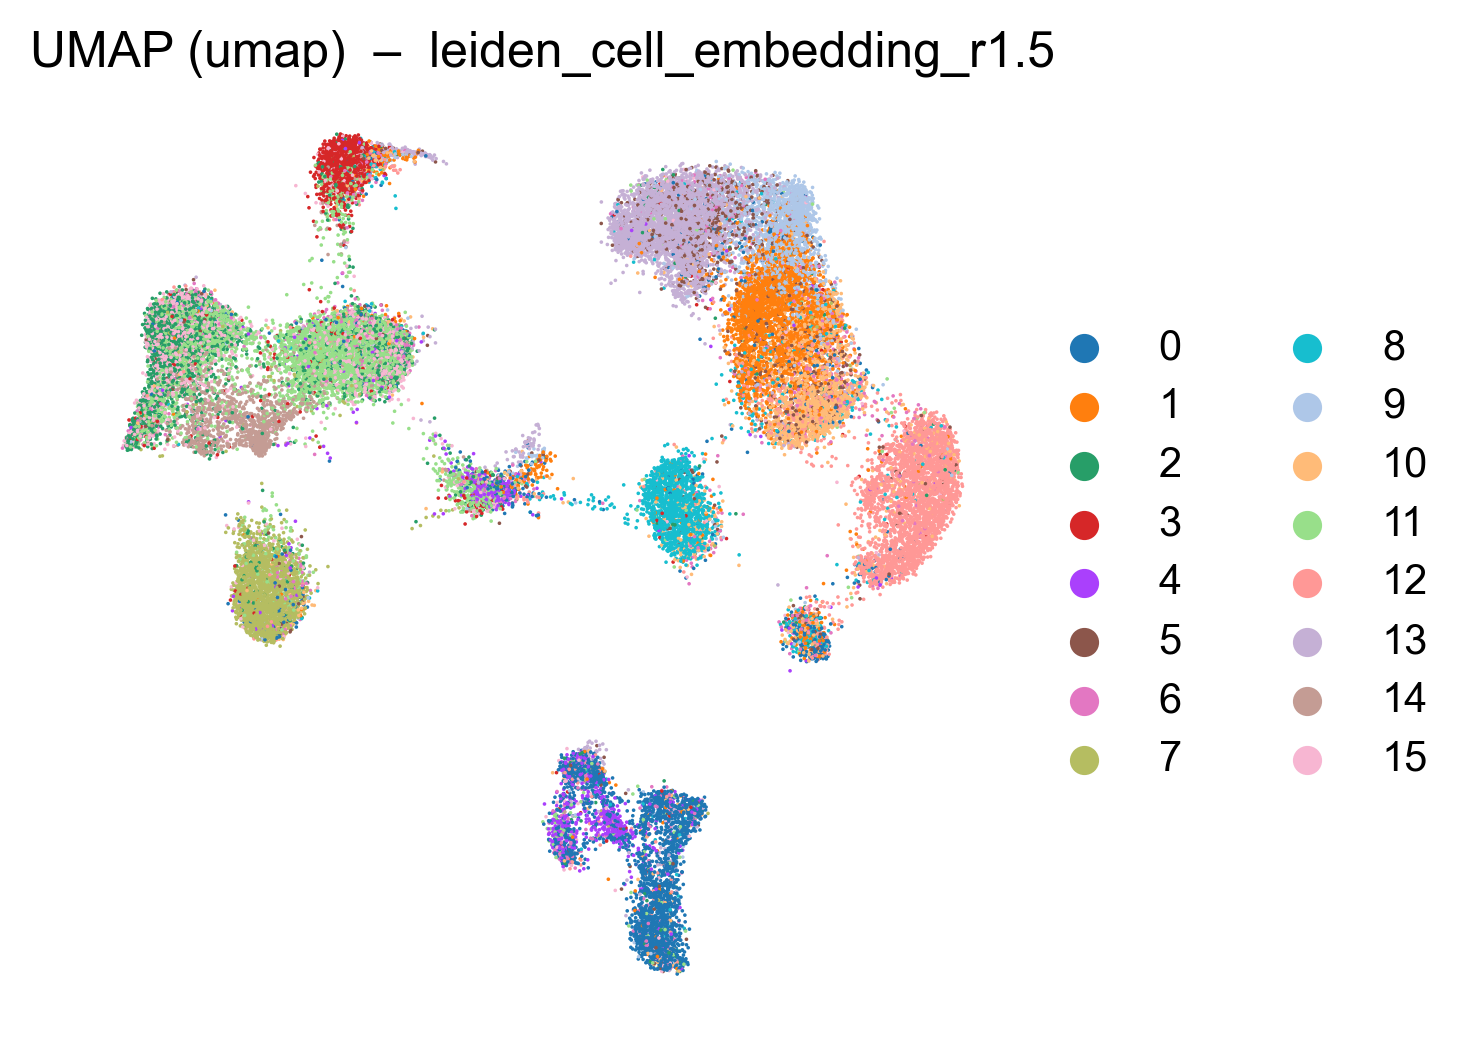

In [22]:
plot_umap(adata = adata, 
          umap_key = "Umap", 
          color_col = 'leiden_cell_embedding_r1.5',
          output_dir = '', 
          figsize = (4,4), 
          dpi = 300, )

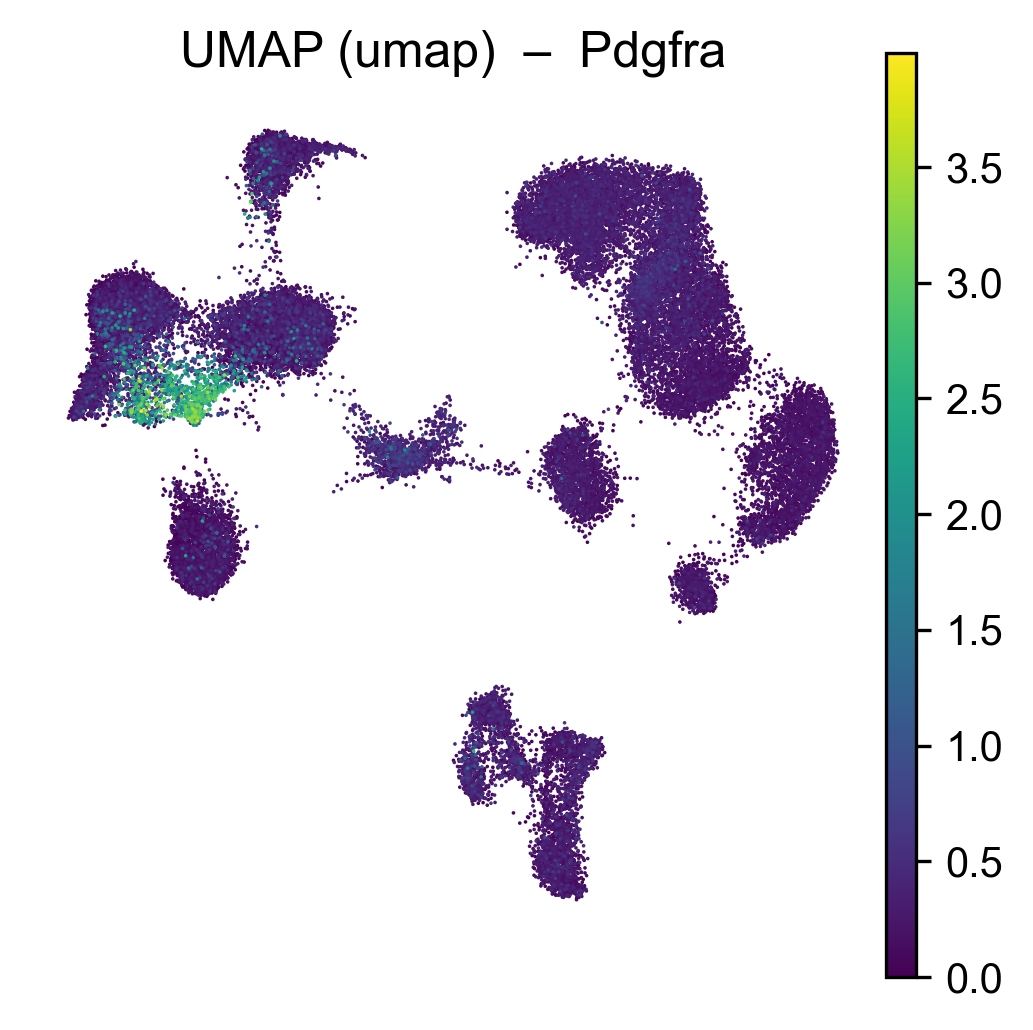

In [23]:
plot_umap(adata = adata, 
          umap_key = "Umap", 
          color_col = 'Pdgfra',
          output_dir = '', 
          figsize = (4,4), 
          dpi = 300, use_raw = False)

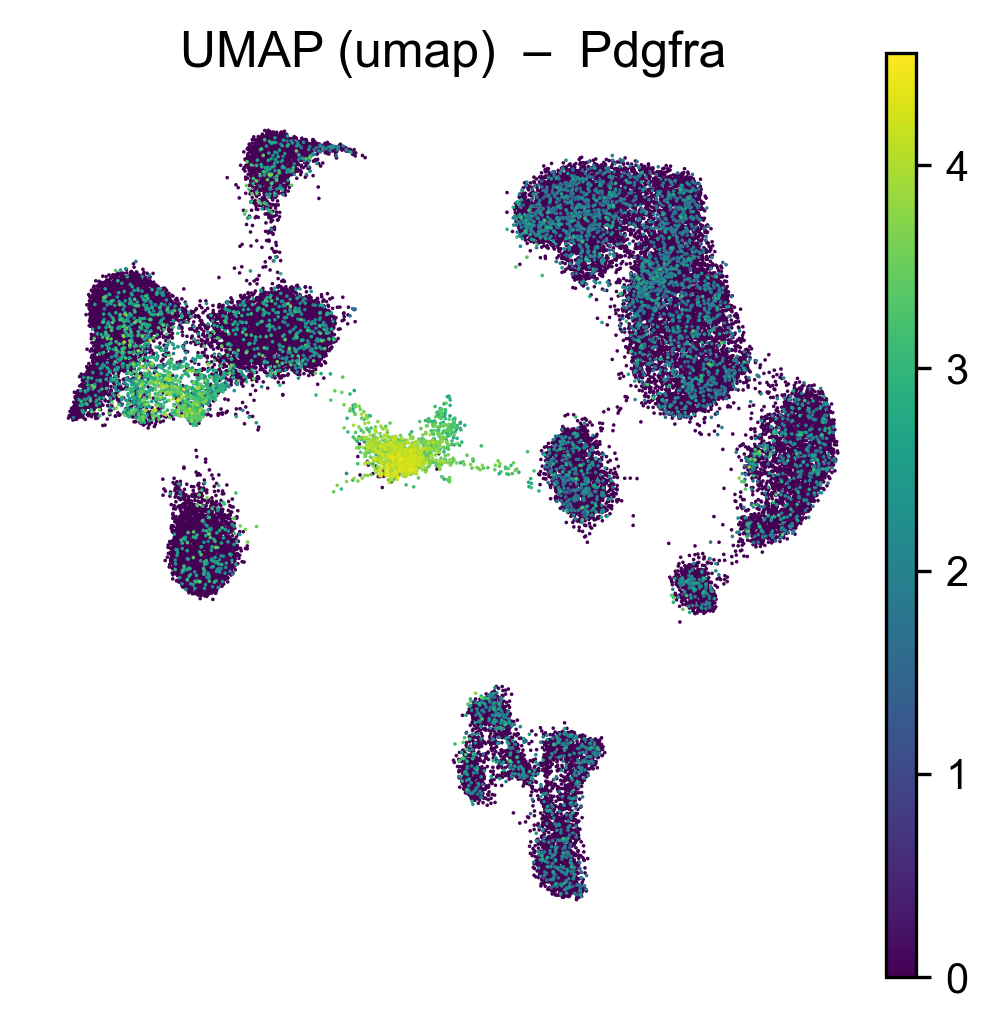

In [24]:
plot_umap(adata = adata, 
          umap_key = "Umap", 
          color_col = 'Pdgfra',
          output_dir = '', 
          figsize = (4,4), 
          dpi = 300, use_raw = True)

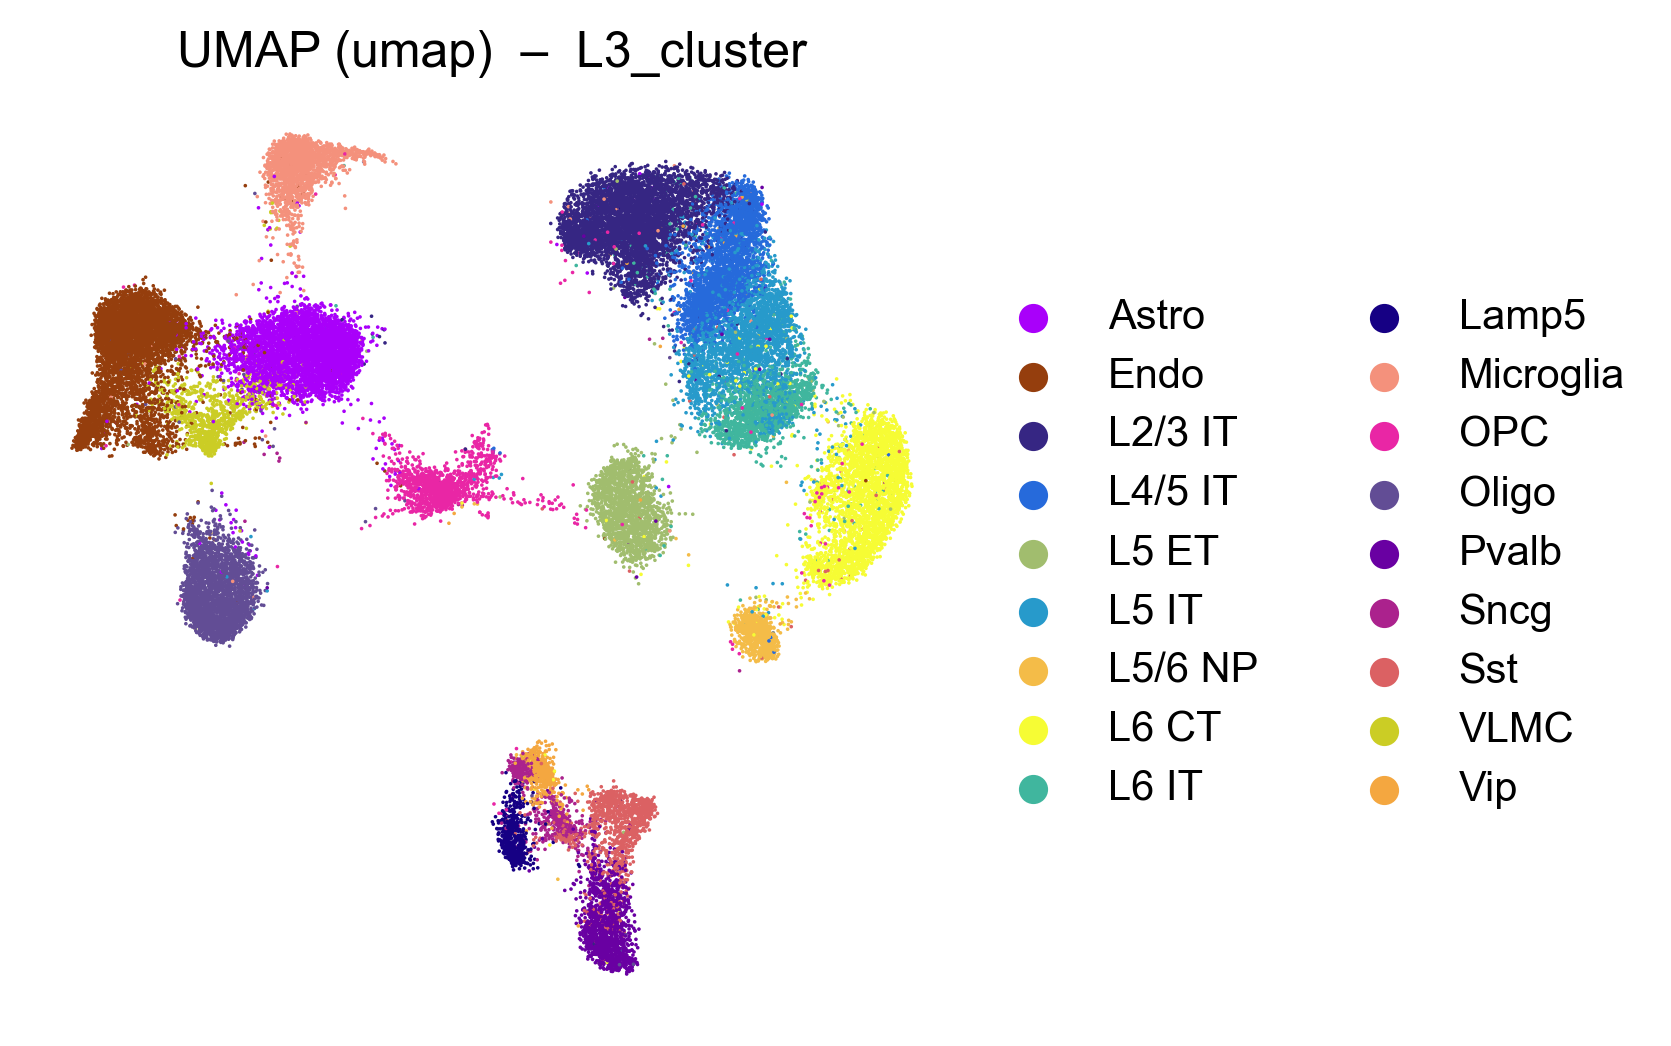

In [12]:
plot_umap(adata = adata, 
          umap_key = "Umap", 
          color_col = 'L3_cluster',
          output_dir = '', 
          figsize = (4,4), 
          dpi = 300, 
          colormap = colormap)

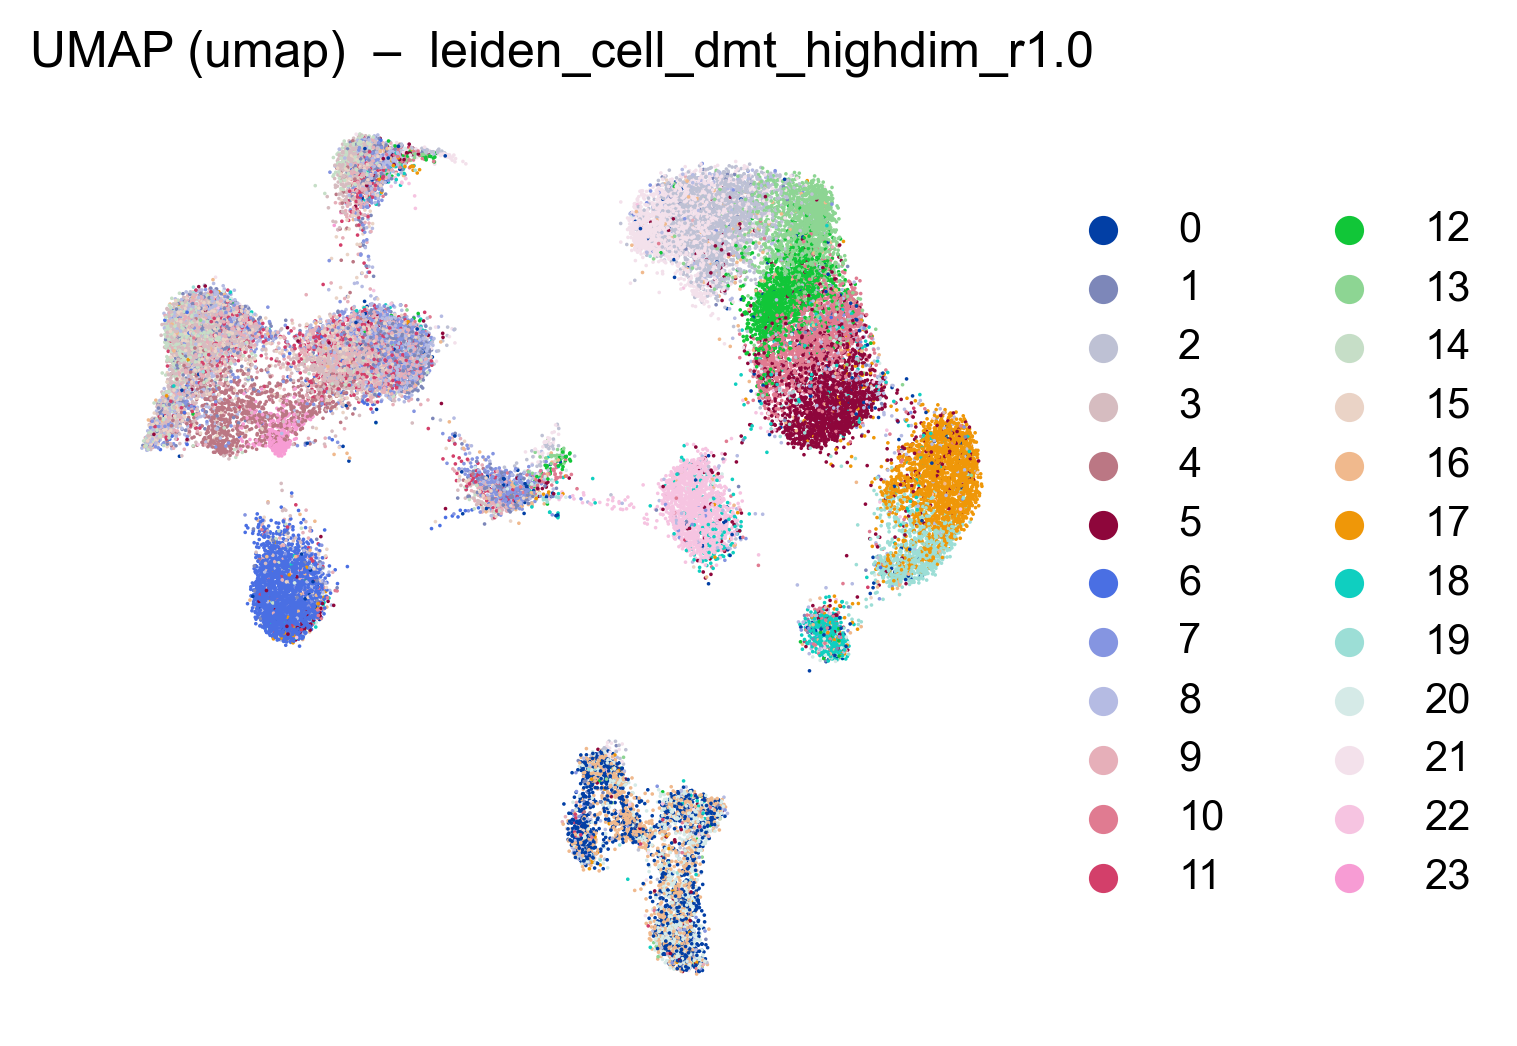

In [8]:
plot_umap(adata = adata, 
          umap_key = "Umap", 
          color_col = 'leiden_cell_dmt_highdim_r1.0',
          output_dir = '', 
          figsize = (4,4), 
          dpi = 300, )

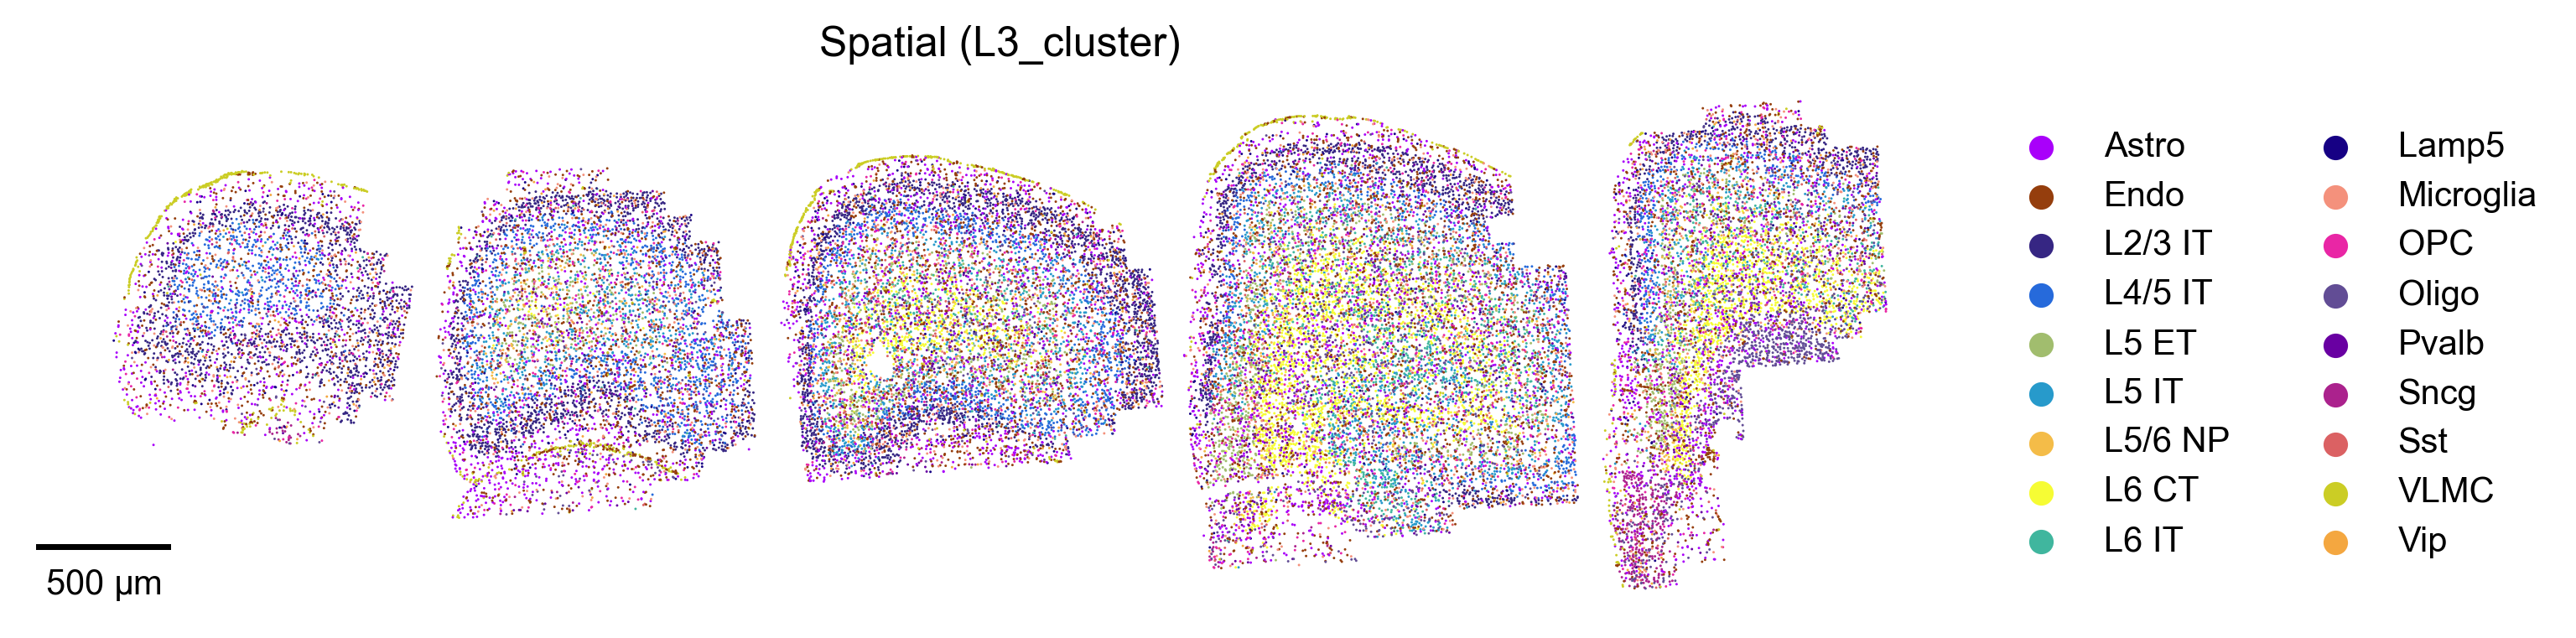

In [40]:
plot_spatial(adata = adata, 
             color_col = 'L3_cluster', 
             output_dir = 'asdas',
             scale_factor = 0.1, 
             figsize = (10,10), 
             dpi = 300, 
             colormap = colormap)

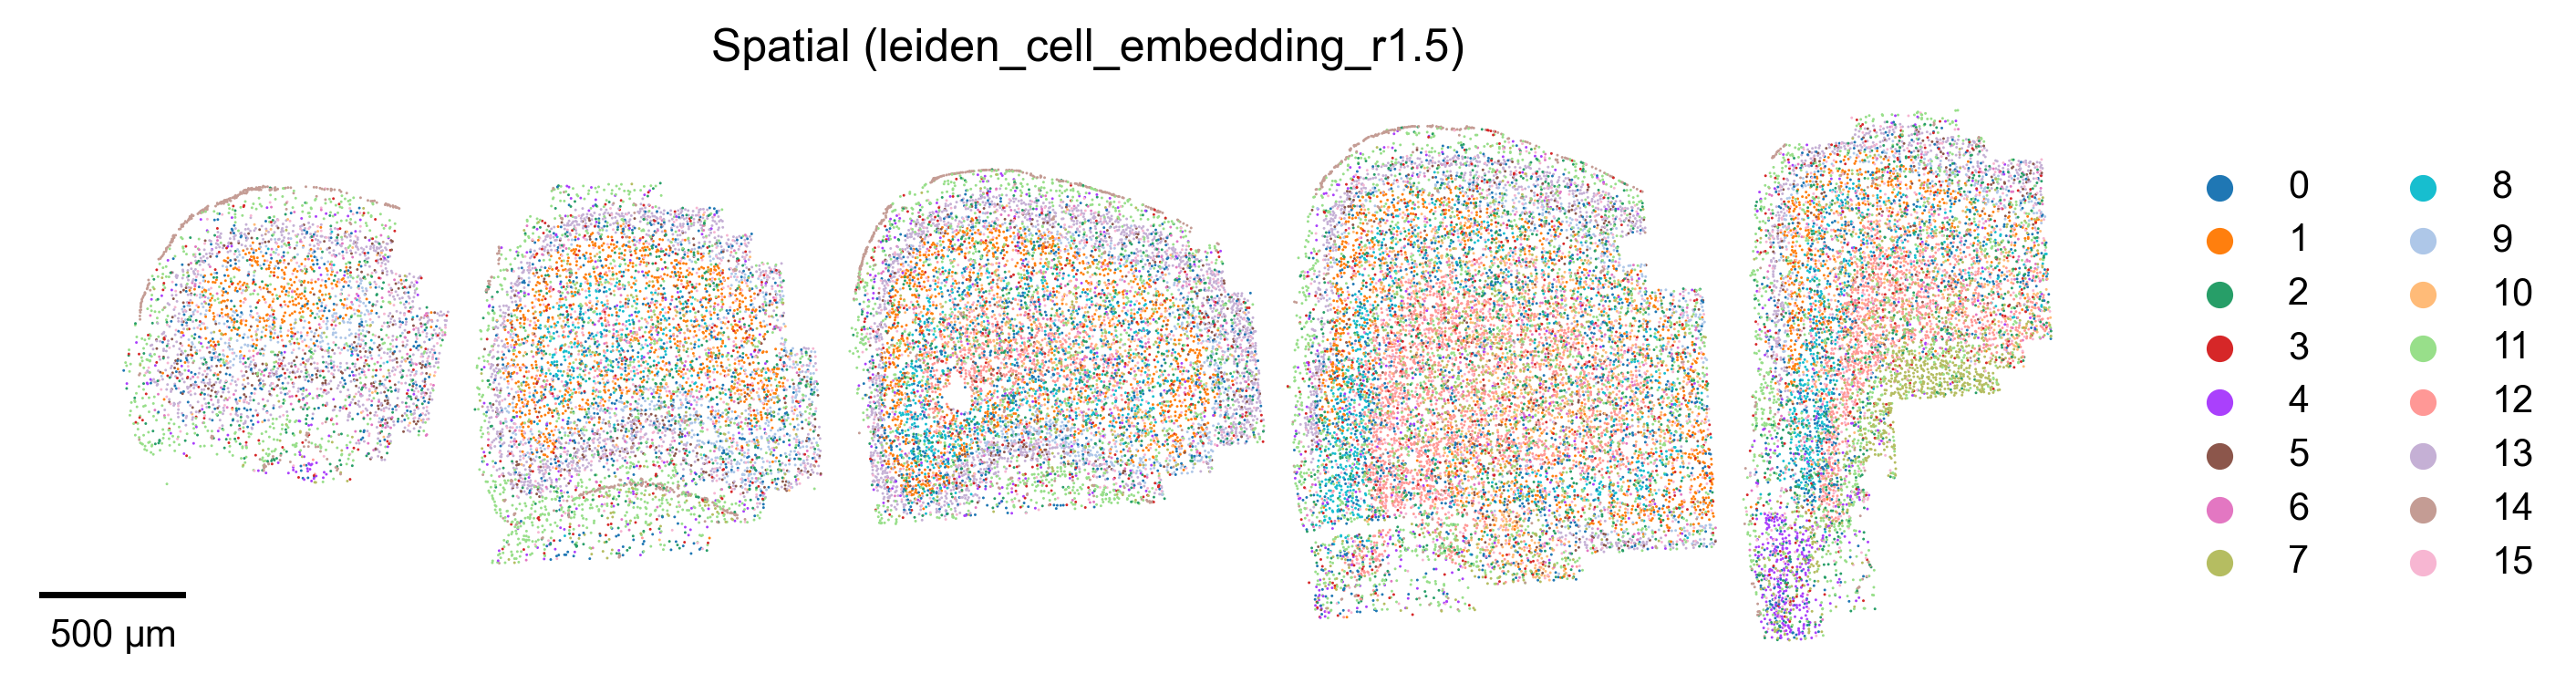

In [27]:
plot_spatial(adata = adata, 
             color_col = 'leiden_cell_embedding_r1.5', 
             output_dir = 'asdas',
             scale_factor = 0.1, 
             figsize = (10,10), 
             dpi = 300)

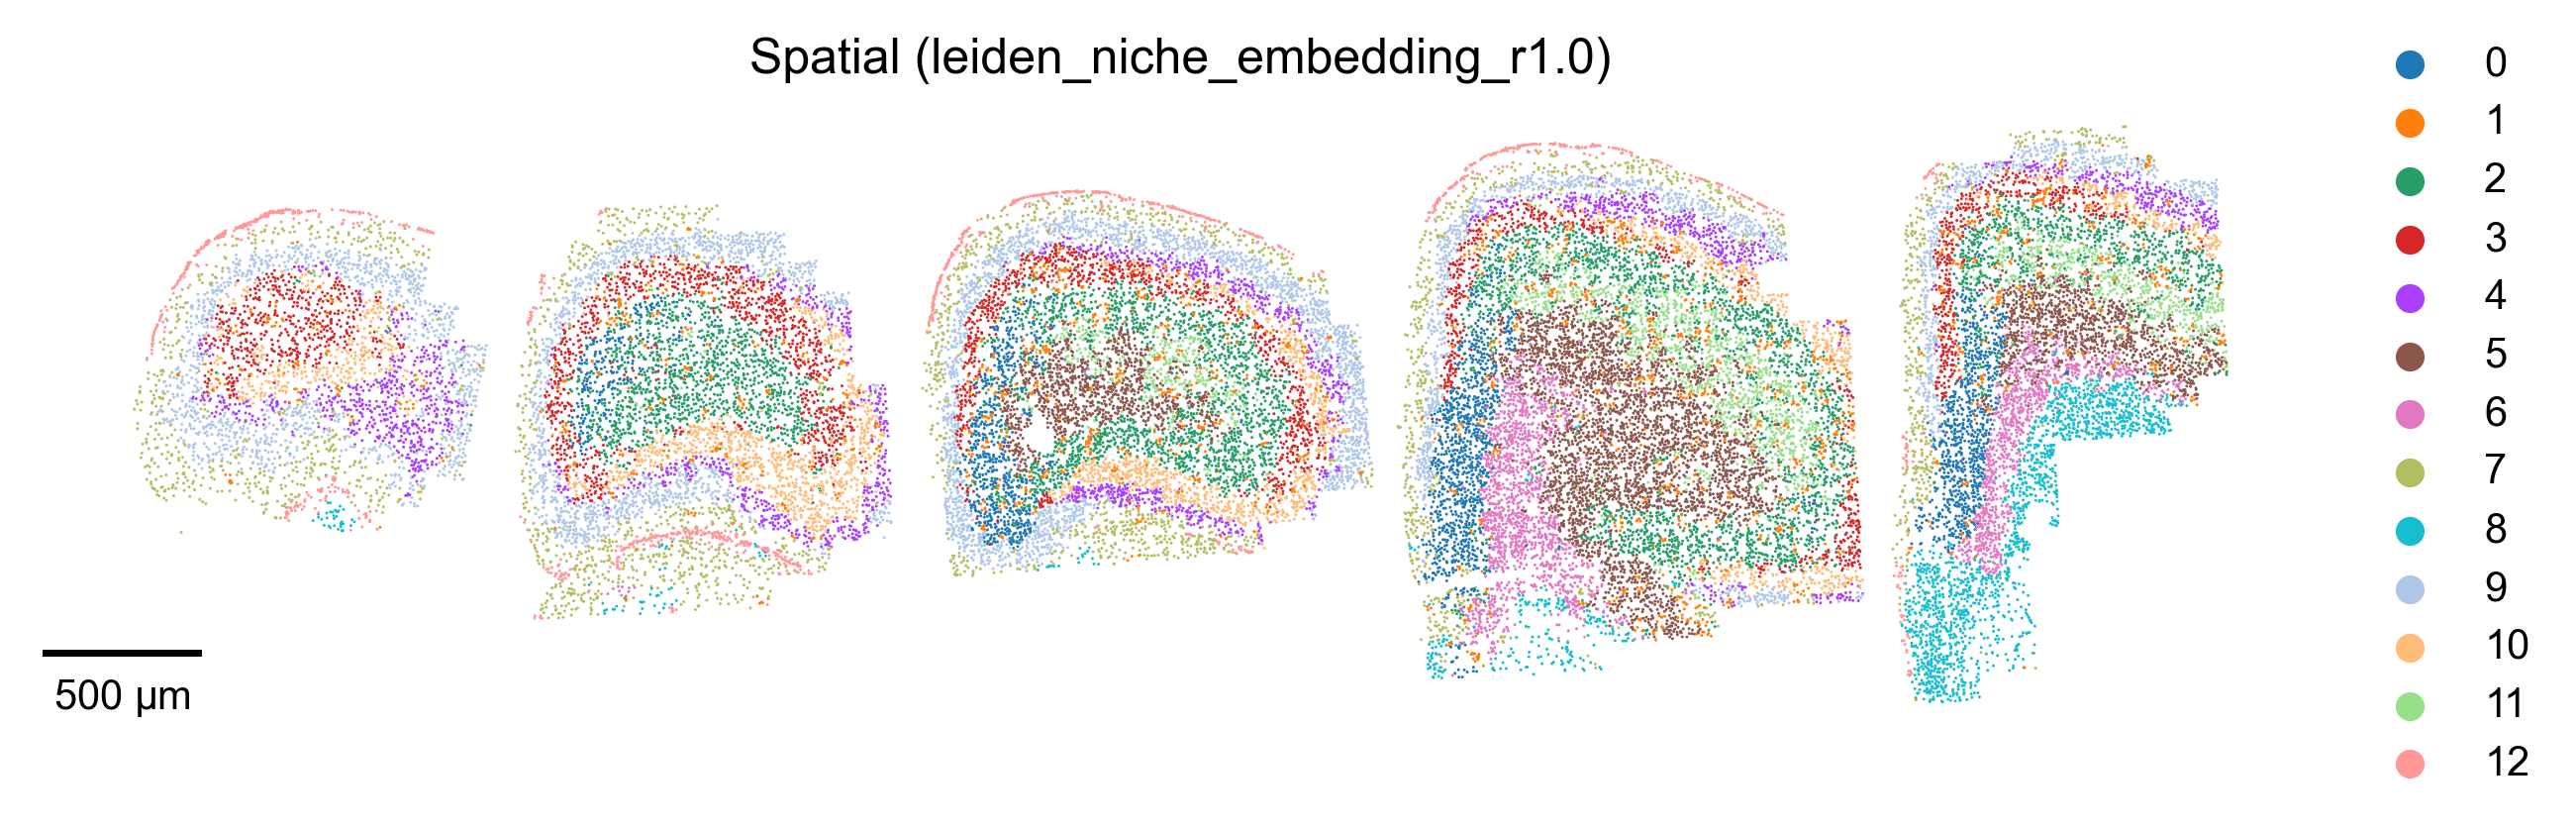

In [25]:
plot_spatial(adata = adata, 
             color_col = 'leiden_niche_embedding_r1.0', 
             output_dir = 'asdas',
             scale_factor = 0.1, 
             figsize = (10,10), 
             dpi = 300)